# Phase II — Latent Space Analysis & Morphology Continuum

Input: Best-trained EfficientNet-B2 encoders from Phase I (SetA, SetB checkpoints).
Extract 1408-dim embeddings for SetA, SetB, NTU test patches. Fit UMAP for visualisation.
Compute a morphology progression axis and detect transition regions.

## 0 · Environment Setup

`pip install umap-learn` required if not installed.

In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import umap

warnings.filterwarnings('ignore')

print(f'PyTorch  {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'MPS  available : {torch.backends.mps.is_available()}')

PyTorch  2.11.0
CUDA available : False
MPS  available : True


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f'Reproducibility seed: {SEED}')

Reproducibility seed: 42


## 1 · Configuration

Each entry in `SOURCES` binds a test directory to its Phase I checkpoint.

In [4]:
CONFIG = {
    # ── Data
    'data_root'   : 'Data',
    'image_size'  : 224,
    'batch_size'  : 64,       # larger batch fine for inference-only
    'num_workers' : 0,        # must be 0 in notebooks on macOS
    'num_classes' : 5,
    'seed'        : SEED,

    # ── Phase I checkpoints
    'ckpt_setA' : 'outputs/seta/checkpoints/best_model.pth',
    'ckpt_setB' : 'outputs/setb/checkpoints/best_model.pth',

    # ── Output
    'output_dir' : 'outputs/phase2',

    # ── UMAP
    'umap_n_neighbors' : 30,
    'umap_min_dist'    : 0.1,
    'umap_metric'      : 'cosine',

    # ── Transition detection thresholds
    'low_margin_thresh' : 0.15,   # top-2 probability gap below this → ambiguous
    'high_conf_thresh'  : 0.70,   # confidence above this → high-confidence prediction
}

CLASS_NAMES = ['Stroma', 'Normal', 'G3', 'G4', 'G5']
CLASS_MAP   = {name: idx for idx, name in enumerate(CLASS_NAMES)}

CLASS_COLORS = {
    'Stroma' : '#4CAF50',
    'Normal' : '#2196F3',
    'G3'     : '#FF9800',
    'G4'     : '#F44336',
    'G5'     : '#9C27B0',
}

SOURCES = [
    {
        'label'    : 'SetA',
        'test_dir' : os.path.join(CONFIG['data_root'], 'SetA', '251_Test_A'),
        'ckpt'     : CONFIG['ckpt_setA'],
    },
    {
        'label'    : 'SetB',
        'test_dir' : os.path.join(CONFIG['data_root'], 'SetB', '251_Test_B'),
        'ckpt'     : CONFIG['ckpt_setB'],
    },
    {
        'label'    : 'NTU',
        'test_dir' : os.path.join(CONFIG['data_root'], 'Test_NTU_additional'),
        'ckpt'     : CONFIG['ckpt_setA'],  # change to ckpt_setB if preferred
    },
]
print(f'Sources: {[s["label"] for s in SOURCES]}')

Sources: ['SetA', 'SetB', 'NTU']


In [5]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

for sub in ['embeddings', 'figures', 'reports']:
    os.makedirs(os.path.join(CONFIG['output_dir'], sub), exist_ok=True)
print(f'Output root: {CONFIG["output_dir"]}')

Device: mps
Output root: outputs/phase2


## 2 · Embedding Extraction

Frozen inference on every test set. Each patch yields a 1408-dim embedding
(EfficientNet-B2 penultimate layer), true label, predicted label, softmax probabilities,
confidence, and correctness flag.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_test_transform(image_size: int) -> T.Compose:
    return T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


class HistoDataset(Dataset):
    """
    Reads H&E patches from disk.
    Returns (image_tensor, label_int, path_str) so we can track patch identity.
    """
    def __init__(self, root_dir: str, class_map: dict, transform=None):
        self.transform = transform
        self.samples: list[tuple[str, int]] = []
        for class_name, label in class_map.items():
            class_dir = Path(root_dir) / class_name
            if not class_dir.exists():
                continue
            for p in sorted(class_dir.glob('*.tif')):
                self.samples.append((str(p), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, path

In [7]:
def _build_base_model(num_classes: int = 5) -> nn.Module:
    model = models.efficientnet_b2(
        weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1
    )
    in_features = model.classifier[1].in_features   # 1408
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


class EmbeddingExtractor(nn.Module):
    """
    Wraps EfficientNet-B2.
    forward() returns (embedding: Tensor[B,1408], logits: Tensor[B,5])
    in one pass — no redundant computation.
    """
    def __init__(self, full_model: nn.Module):
        super().__init__()
        self.features   = full_model.features
        self.avgpool    = full_model.avgpool
        self.classifier = full_model.classifier   # Dropout + Linear

    def forward(self, x: torch.Tensor):
        x    = self.features(x)
        x    = self.avgpool(x)
        embs = torch.flatten(x, 1)                # (B, 1408)
        logits = self.classifier(embs)             # (B, 5)
        return embs, logits


def load_extractor(ckpt_path: str, device: torch.device) -> EmbeddingExtractor:
    full_model = _build_base_model(num_classes=CONFIG['num_classes'])
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    full_model.load_state_dict(ckpt['model_state_dict'])
    full_model.eval().to(device)
    extractor = EmbeddingExtractor(full_model).eval().to(device)
    print(f'  checkpoint : {ckpt_path}')
    print(f'  epoch      : {ckpt["epoch"]}   val Macro F1 = {ckpt["val_macro_f1"]:.4f}')
    return extractor

In [8]:
@torch.no_grad()
def extract_embeddings(
    extractor : EmbeddingExtractor,
    dataset   : HistoDataset,
    batch_size: int,
    num_workers: int,
    device    : torch.device,
) -> tuple[pd.DataFrame, np.ndarray]:
    """
    Run inference on dataset; return (metadata_df, embedding_matrix).
    embedding_matrix shape: (N, 1408)
    """
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type not in ('cpu', 'mps')),
    )

    all_paths, all_true = [], []
    all_embs,  all_probs = [], []

    for images, labels, paths in loader:
        images       = images.to(device)
        embs, logits = extractor(images)
        probs        = F.softmax(logits, dim=1)

        all_paths.extend(paths)
        all_true.extend(labels.numpy())
        all_embs.append(embs.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_embs  = np.vstack(all_embs)     # (N, 1408)
    all_probs = np.vstack(all_probs)    # (N, 5)
    all_true  = np.array(all_true)
    all_pred  = all_probs.argmax(axis=1)
    confidence = all_probs.max(axis=1)
    correct    = (all_true == all_pred).astype(int)

    df = pd.DataFrame({
        'path'            : all_paths,
        'true_label'      : all_true,
        'true_label_name' : [CLASS_NAMES[i] for i in all_true],
        'pred_label'      : all_pred,
        'pred_label_name' : [CLASS_NAMES[i] for i in all_pred],
        'confidence'      : confidence,
        'correct'         : correct,
    })
    for i, name in enumerate(CLASS_NAMES):
        df[f'prob_{name}'] = all_probs[:, i]

    return df, all_embs

In [9]:
# ── Run extraction over all sources ──────────────────────────────────────────
emb_dir = os.path.join(CONFIG['output_dir'], 'embeddings')
all_dfs, all_embs_list = [], []

for src in SOURCES:
    print(f'\n── {src["label"]} ───────────────────────────────────────────')
    extractor = load_extractor(src['ckpt'], device)
    dataset   = HistoDataset(
        root_dir  = src['test_dir'],
        class_map = CLASS_MAP,
        transform = get_test_transform(CONFIG['image_size']),
    )
    print(f'  patches: {len(dataset)}')
    df, embs = extract_embeddings(
        extractor, dataset,
        CONFIG['batch_size'], CONFIG['num_workers'], device,
    )
    df['source'] = src['label']

    # per-source saves
    df.to_csv(os.path.join(emb_dir, f'embeddings_{src["label"].lower()}.csv'), index=False)
    np.save(os.path.join(emb_dir, f'embeddings_{src["label"].lower()}.npy'), embs)

    acc = df['correct'].mean() * 100
    f1_macro = f1_score_from_df(df) if False else float('nan')   # placeholder; see below
    print(f'  accuracy : {acc:.1f}%')

    all_dfs.append(df)
    all_embs_list.append(embs)
    del extractor   # free GPU memory between sources

emb_df     = pd.concat(all_dfs, ignore_index=True)
emb_matrix = np.vstack(all_embs_list)   # (N_total, 1408)

print(f'\n{"─"*50}')
print(f'Total patches    : {len(emb_df)}')
print(f'Embedding matrix : {emb_matrix.shape}')
print(f'Source breakdown :')
print(emb_df['source'].value_counts().to_string())


── SetA ───────────────────────────────────────────
  checkpoint : outputs/seta/checkpoints/best_model.pth
  epoch      : 11   val Macro F1 = 0.9293
  patches: 1000
  accuracy : 94.1%

── SetB ───────────────────────────────────────────
  checkpoint : outputs/setb/checkpoints/best_model.pth
  epoch      : 21   val Macro F1 = 0.9568
  patches: 1000
  accuracy : 95.3%

── NTU ───────────────────────────────────────────
  checkpoint : outputs/seta/checkpoints/best_model.pth
  epoch      : 11   val Macro F1 = 0.9293
  patches: 1000
  accuracy : 50.2%

──────────────────────────────────────────────────
Total patches    : 3000
Embedding matrix : (3000, 1408)
Source breakdown :
source
SetA    1000
SetB    1000
NTU     1000


In [10]:
from sklearn.metrics import f1_score

print('Per-source accuracy & Macro F1:')
print(f'{"Source":8s}  {"Acc":>6s}  {"Macro F1":>9s}')
print('─' * 28)
for src_label in emb_df['source'].unique():
    sub = emb_df[emb_df['source'] == src_label]
    acc  = sub['correct'].mean() * 100
    mf1  = f1_score(sub['true_label'], sub['pred_label'], average='macro') * 100
    print(f'{src_label:8s}  {acc:6.2f}%  {mf1:9.2f}%')

Per-source accuracy & Macro F1:
Source       Acc   Macro F1
────────────────────────────
SetA       94.10%      93.98%
SetB       95.30%      95.30%
NTU        50.20%      45.73%


## 3 · Latent Space — UMAP

Pipeline: StandardScaler → PCA(50) → UMAP(cosine, n_neighbors=30).
Four panels: true label, predicted label, confidence, domain (source).

In [11]:
# ── 1. Standardise ───────────────────────────────────────────────────────────
scaler     = StandardScaler()
emb_scaled = scaler.fit_transform(emb_matrix)

# ── 2. PCA to 50 dims ─────────────────────────────────────────────────────────
pca     = PCA(n_components=50, random_state=CONFIG['seed'])
emb_pca = pca.fit_transform(emb_scaled)
print(f'PCA 50-component explained variance: {pca.explained_variance_ratio_.sum():.3f}')

# ── 3. UMAP ───────────────────────────────────────────────────────────────────
reducer = umap.UMAP(
    n_neighbors  = CONFIG['umap_n_neighbors'],
    min_dist     = CONFIG['umap_min_dist'],
    metric       = CONFIG['umap_metric'],
    random_state = CONFIG['seed'],
    verbose      = True,
)
emb_2d = reducer.fit_transform(emb_pca)

emb_df['umap_x'] = emb_2d[:, 0]
emb_df['umap_y'] = emb_2d[:, 1]
print(f'UMAP complete — shape: {emb_2d.shape}')

PCA 50-component explained variance: 0.869
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Sat Apr  4 16:08:22 2026 Construct fuzzy simplicial set
Sat Apr  4 16:08:25 2026 Finding Nearest Neighbors
Sat Apr  4 16:08:27 2026 Finished Nearest Neighbor Search
Sat Apr  4 16:08:28 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sat Apr  4 16:08:31 2026 Finished embedding
UMAP complete — shape: (3000, 2)


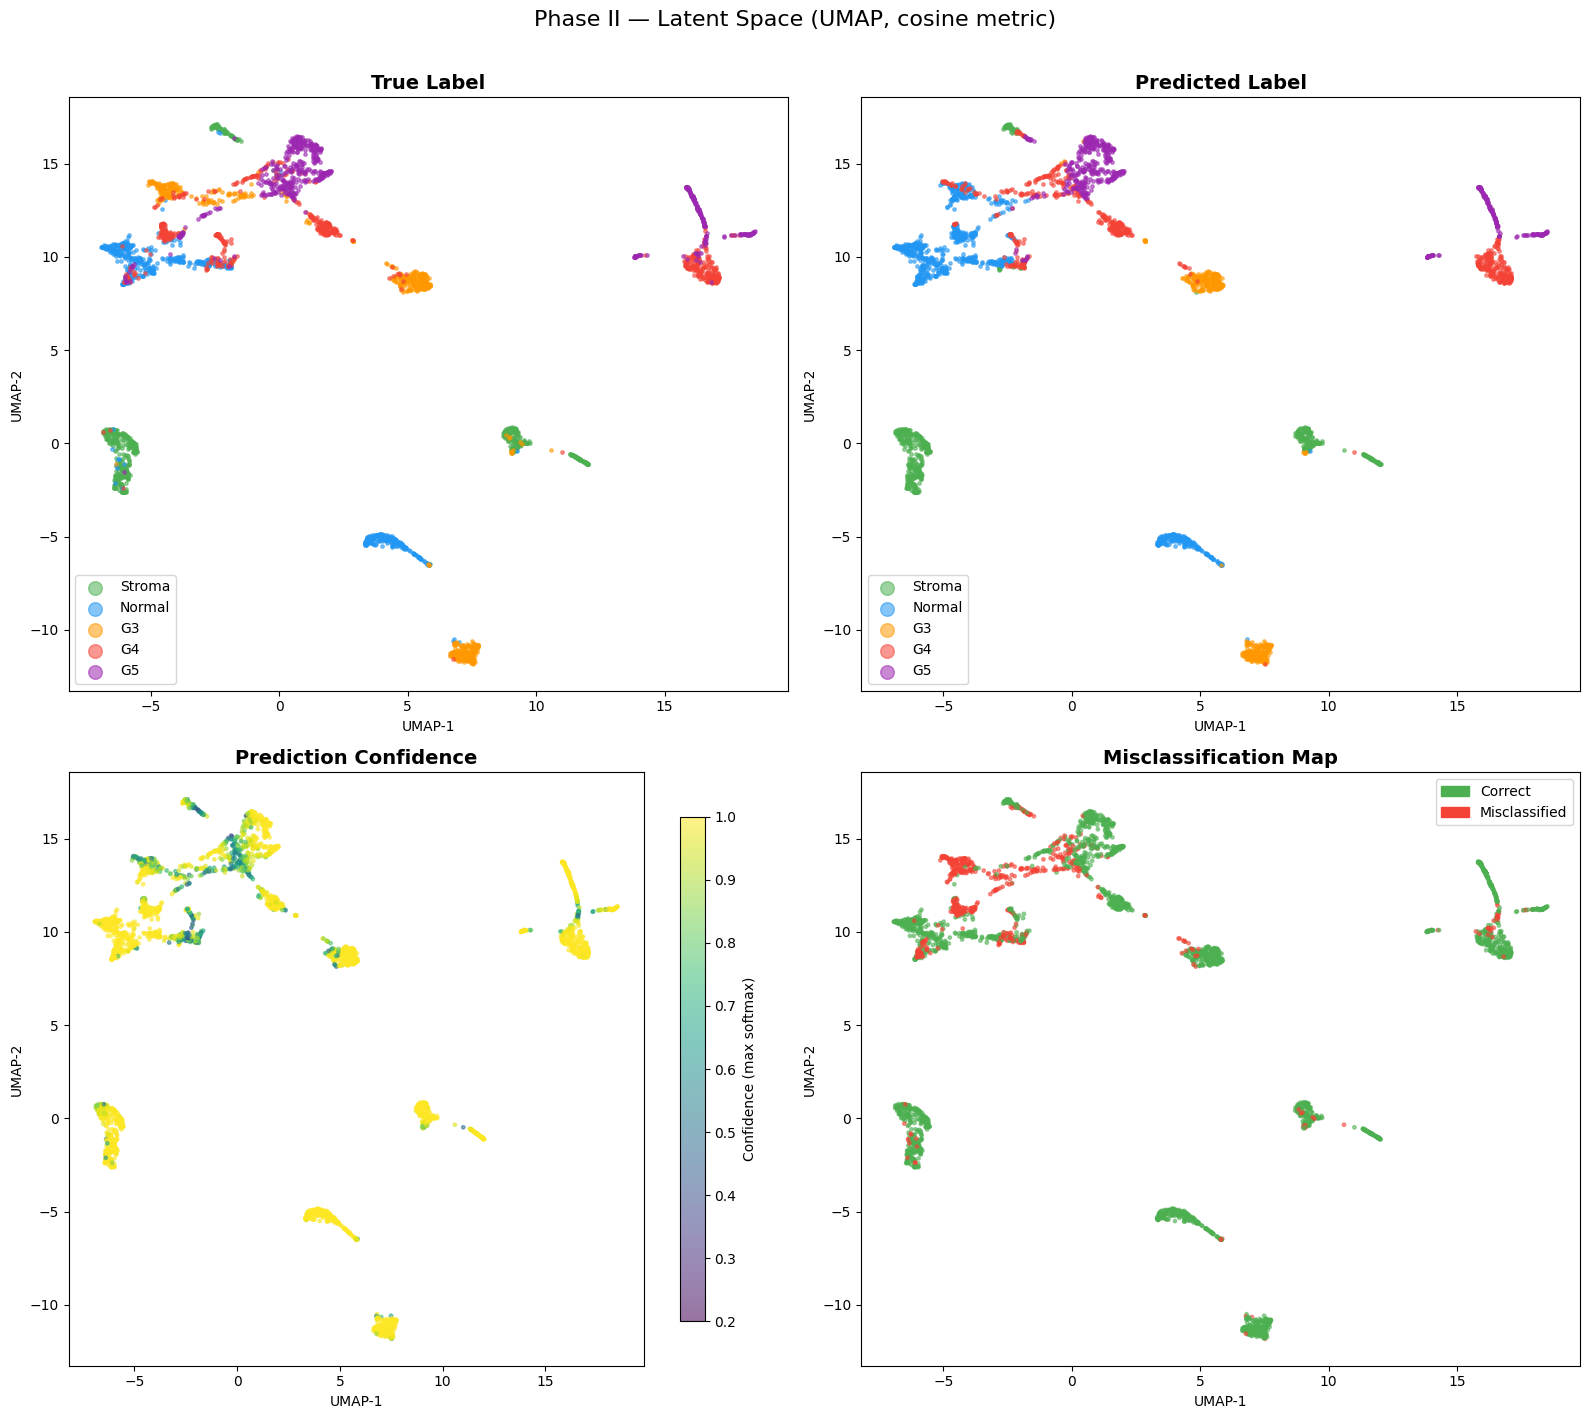

Saved → outputs/phase2/figures/umap_4panel.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
s, alpha = 6, 0.55

# ── Panel 1: True label ───────────────────────────────────────────────────────
ax = axes[0]
for name in CLASS_NAMES:
    m = emb_df['true_label_name'] == name
    ax.scatter(emb_df.loc[m, 'umap_x'], emb_df.loc[m, 'umap_y'],
               c=CLASS_COLORS[name], label=name, s=s, alpha=alpha)
ax.set_title('True Label', fontsize=14, fontweight='bold')
ax.legend(markerscale=4, fontsize=10, framealpha=0.8)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# ── Panel 2: Predicted label ──────────────────────────────────────────────────
ax = axes[1]
for name in CLASS_NAMES:
    m = emb_df['pred_label_name'] == name
    ax.scatter(emb_df.loc[m, 'umap_x'], emb_df.loc[m, 'umap_y'],
               c=CLASS_COLORS[name], label=name, s=s, alpha=alpha)
ax.set_title('Predicted Label', fontsize=14, fontweight='bold')
ax.legend(markerscale=4, fontsize=10, framealpha=0.8)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# ── Panel 3: Confidence ───────────────────────────────────────────────────────
ax = axes[2]
sc = ax.scatter(emb_df['umap_x'], emb_df['umap_y'],
                c=emb_df['confidence'], cmap='viridis', s=s, alpha=alpha,
                vmin=0.2, vmax=1.0)
plt.colorbar(sc, ax=ax, label='Confidence (max softmax)', shrink=0.85)
ax.set_title('Prediction Confidence', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# ── Panel 4: Misclassification map ────────────────────────────────────────────
ax = axes[3]
colors = emb_df['correct'].map({1: '#4CAF50', 0: '#F44336'})
ax.scatter(emb_df['umap_x'], emb_df['umap_y'], c=colors, s=s, alpha=alpha)
legend_handles = [
    mpatches.Patch(color='#4CAF50', label='Correct'),
    mpatches.Patch(color='#F44336', label='Misclassified'),
]
ax.legend(handles=legend_handles, fontsize=10, framealpha=0.8)
ax.set_title('Misclassification Map', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

fig.suptitle('Phase II — Latent Space (UMAP, cosine metric)', fontsize=16, y=1.01)
plt.tight_layout()
fig_path = os.path.join(CONFIG['output_dir'], 'figures', 'umap_4panel.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

## 4 · Progression Axis (G3 to G5)

A scalar morphology score is computed by projecting every embedding onto the
G3-centroid to G5-centroid axis in the full 1408-dimensional space.

```
axis_vec  = (centroid_G5 - centroid_G3) / ||centroid_G5 - centroid_G3||
score(x)  = (x - centroid_G3) · axis_vec
```

**Important caveat:** the axis is defined by the G3 and G5 centroids computed
from these same test patches, so the finding that G3 and G5 project near their
respective endpoints is guaranteed by construction. The genuinely informative
results are (1) that G4 lands between them rather than forming a separate cluster,
and (2) that G4 has a wider score distribution than G3 or G5, indicating it
occupies a more diffuse region of feature space. Stroma and Normal also project
onto the axis at intermediate positions because the axis does not account for
non-cancer tissue; the progression score should only be interpreted for
grade 3 to grade 5 patches.

In [13]:
# ── Compute class centroids in 1408-dim space ────────────────────────────────
class_centroids = {}
for c in CLASS_NAMES:
    mask = emb_df['true_label_name'] == c
    class_centroids[c] = emb_matrix[mask.values].mean(axis=0)

# ── Progression axis ──────────────────────────────────────────────────────────
centroid_G3 = class_centroids['G3']
centroid_G5 = class_centroids['G5']

raw_axis  = centroid_G5 - centroid_G3
axis_vec  = raw_axis / np.linalg.norm(raw_axis)    # unit vector
axis_len  = np.linalg.norm(raw_axis)

# Projection: score = (emb - centroid_G3) · axis_vec
emb_df['progression_score'] = (emb_matrix - centroid_G3) @ axis_vec

print(f'G3→G5 axis length (Euclidean, 1408-dim): {axis_len:.2f}')
print()
print(f'Progression score  mean ± std:')
for c in CLASS_NAMES:
    v = emb_df.loc[emb_df['true_label_name'] == c, 'progression_score']
    print(f'  {c:8s}:  {v.mean():+7.3f} ± {v.std():.3f}')

G3→G5 axis length (Euclidean, 1408-dim): 19.23

Progression score  mean ± std:
  Stroma  :  +10.638 ± 2.010
  Normal  :   +7.249 ± 2.564
  G3      :   +0.000 ± 7.281
  G4      :   +9.255 ± 4.287
  G5      :  +19.229 ± 4.287


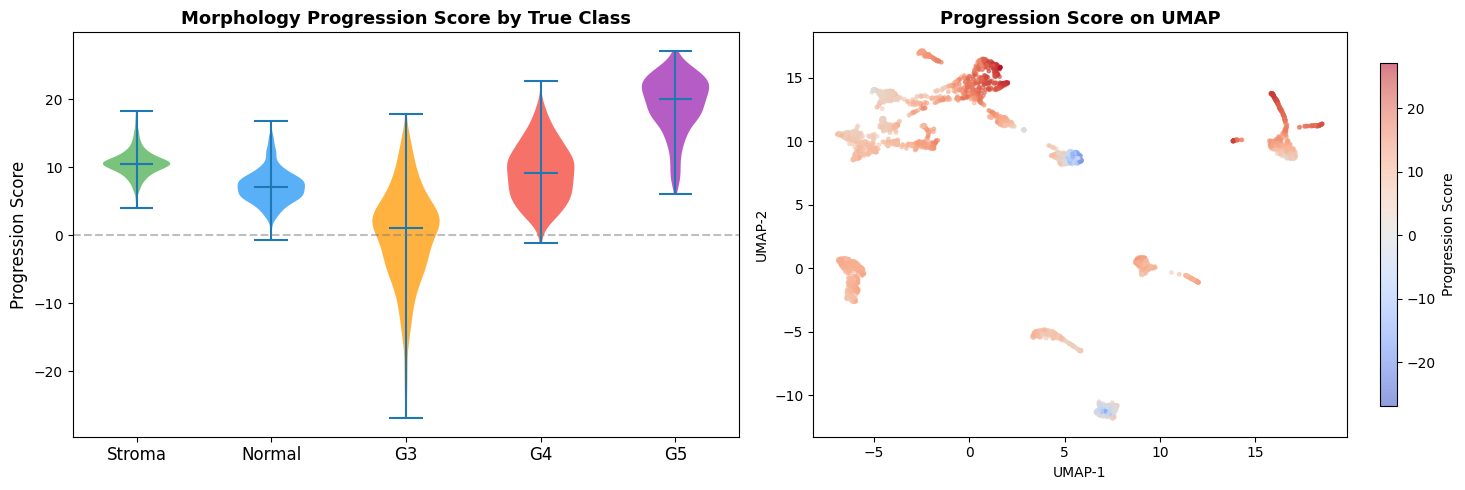

Saved → outputs/phase2/figures/progression_axis.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: violin per class ────────────────────────────────────────────────────
ax = axes[0]
data_by_class = [
    emb_df.loc[emb_df['true_label_name'] == c, 'progression_score'].values
    for c in CLASS_NAMES
]
vp = ax.violinplot(data_by_class, positions=range(len(CLASS_NAMES)),
                   showmedians=True, showextrema=True)
for pc, c in zip(vp['bodies'], CLASS_NAMES):
    pc.set_facecolor(CLASS_COLORS[c])
    pc.set_alpha(0.75)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, fontsize=12)
ax.set_ylabel('Progression Score', fontsize=12)
ax.set_title('Morphology Progression Score by True Class', fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# ── Right: UMAP coloured by progression score ─────────────────────────────────
ax = axes[1]
sc = ax.scatter(emb_df['umap_x'], emb_df['umap_y'],
                c=emb_df['progression_score'], cmap='coolwarm', s=6, alpha=0.55)
plt.colorbar(sc, ax=ax, label='Progression Score', shrink=0.85)
ax.set_title('Progression Score on UMAP', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

plt.tight_layout()
fig_path = os.path.join(CONFIG['output_dir'], 'figures', 'progression_axis.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

## 5 · Uncertainty and Transition Regions

A patch is flagged as uncertain if either of two criteria holds:

- `low_margin`: gap between top-1 and top-2 softmax probability < 0.15 (model is genuinely undecided)
- `near_boundary`: the patch's nearest class centroid in feature space belongs to a different class than its true label (geometrically displaced toward the wrong attractor)

Note: high-confidence wrong predictions are classification errors, not transition indicators.
A model can be confidently wrong about any patch. These two criteria specifically capture
patches that live near decision boundaries in both probability space and feature space.

In [ ]:
# ── Criterion 1: low margin between top-1 and top-2 softmax ──────────────────
prob_cols = [f'prob_{c}' for c in CLASS_NAMES]
prob_mat  = emb_df[prob_cols].values
top2      = np.sort(prob_mat, axis=1)[:, -2:]
margin    = top2[:, 1] - top2[:, 0]
emb_df['top2_margin'] = margin
emb_df['low_margin']  = (margin < CONFIG['low_margin_thresh']).astype(int)

# ── Criterion 2: nearer to any other centroid than own centroid ───────────────
centroid_matrix = np.vstack([class_centroids[c] for c in CLASS_NAMES])
dist_to_cents   = pairwise_distances(emb_matrix, centroid_matrix, metric='euclidean')

true_idx = emb_df['true_label'].values
own_dist  = dist_to_cents[np.arange(len(emb_df)), true_idx]

temp           = dist_to_cents.copy()
temp[np.arange(len(emb_df)), true_idx] = np.inf
min_other_dist = temp.min(axis=1)

emb_df['near_boundary'] = (min_other_dist < own_dist).astype(int)

# ── Combined flag ─────────────────────────────────────────────────────────────
emb_df['transition'] = (
    emb_df['low_margin'].astype(bool) |
    emb_df['near_boundary'].astype(bool)
).astype(int)

# uncertainty: entropy of softmax (standard measure)
prob_mat_safe = np.clip(prob_mat, 1e-12, 1.0)
emb_df['uncertainty'] = -(prob_mat_safe * np.log(prob_mat_safe)).sum(axis=1)

n  = emb_df['transition'].sum()
N  = len(emb_df)
print(f'Transition patches : {n} / {N}  ({100*n/N:.1f}%)')
print(f'  low_margin       : {emb_df["low_margin"].sum()}')
print(f'  near_boundary    : {emb_df["near_boundary"].sum()}')
print()
print('Transition rate per true class:')
for c in CLASS_NAMES:
    sub  = emb_df[emb_df['true_label_name'] == c]
    rate = sub['transition'].mean() * 100
    print(f'  {c:8s}: {rate:.1f}%')

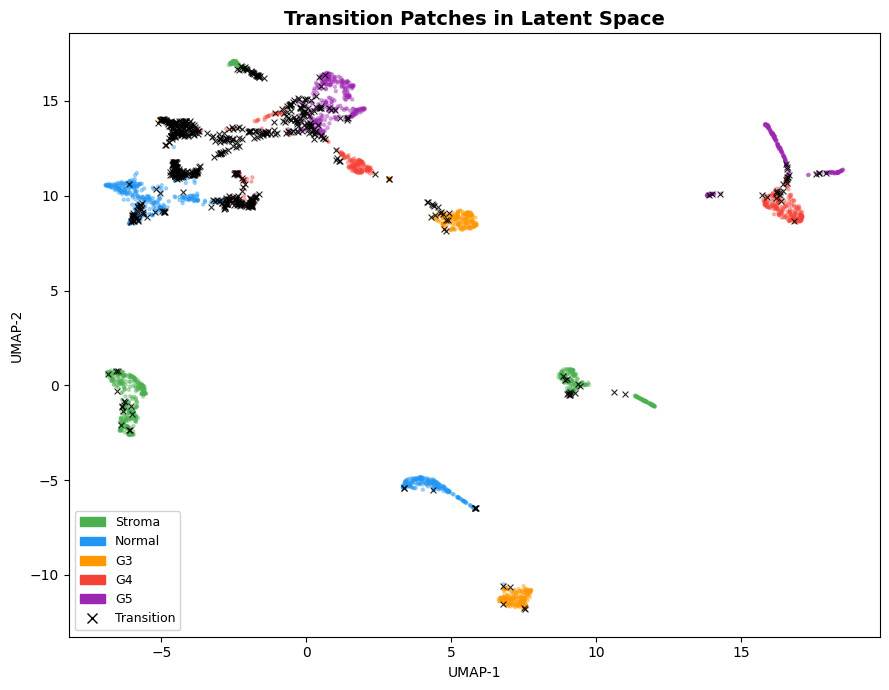

Saved → outputs/phase2/figures/transition_patches_umap.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

# Stable patches: coloured by true class
mask_stable = emb_df['transition'] == 0
stable_colors = [CLASS_COLORS[n] for n in emb_df.loc[mask_stable, 'true_label_name']]
ax.scatter(emb_df.loc[mask_stable, 'umap_x'], emb_df.loc[mask_stable, 'umap_y'],
           c=stable_colors, s=5, alpha=0.35, zorder=1)

# Transition patches: black ×
mask_trans = emb_df['transition'] == 1
ax.scatter(emb_df.loc[mask_trans, 'umap_x'], emb_df.loc[mask_trans, 'umap_y'],
           c='black', s=18, alpha=0.85, marker='x', linewidths=0.8,
           label=f'Transition ({mask_trans.sum()})', zorder=2)

class_handles = [mpatches.Patch(color=CLASS_COLORS[c], label=c) for c in CLASS_NAMES]
trans_handle  = plt.Line2D([0], [0], marker='x', color='black', linestyle='None',
                            markersize=7, label='Transition', markeredgewidth=1)
ax.legend(handles=class_handles + [trans_handle], fontsize=9, framealpha=0.85)
ax.set_title('Transition Patches in Latent Space', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
fig_path = os.path.join(CONFIG['output_dir'], 'figures', 'transition_patches_umap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

## 6 · Prototype Retrieval

Display representative patches: canonical G3/G4/G5 (high-confidence, near centroid),
ambiguous G3–G4 and G4–G5 (lowest top-2 margin between adjacent grades).

In [17]:
def show_patch_panel(
    emb_df    : pd.DataFrame,
    emb_matrix: np.ndarray,
    mask      : np.ndarray,      # boolean array length N
    title     : str,
    n         : int  = 9,
    sort_key  : str  = None,     # column name; None = nearest to centroid
    ascending : bool = True,
    save_path : str  = None,
) -> None:
    """
    Display a row of n representative patches from the masked subset.
    sort_key=None  → nearest to subset centroid (most canonical representatives).
    sort_key=col   → sort by that column (e.g. 'top2_margin' ascending = most ambiguous).
    """
    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f'  {title}: no patches found, skipping.')
        return

    if sort_key is None:
        sub_embs = emb_matrix[indices]
        centroid = sub_embs.mean(axis=0)
        dists    = np.linalg.norm(sub_embs - centroid, axis=1)
        order    = np.argsort(dists)
        selected = indices[order[:n]]
    else:
        sub_df   = emb_df.iloc[indices].sort_values(sort_key, ascending=ascending)
        selected = sub_df.index.to_numpy()[:n]

    n_show = min(n, len(selected))
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 1.6 + 0.5, 2.4))
    if n_show == 1:
        axes = [axes]

    for ax, idx in zip(axes, selected):
        row = emb_df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        ax.imshow(img)
        border_color = CLASS_COLORS.get(row['true_label_name'], 'gray')
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
        ax.set_title(
            f"T:{row['true_label_name']}\nP:{row['pred_label_name']}\n{row['confidence']:.2f}",
            fontsize=7,
        )
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.06)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Canonical G3: 380 candidates


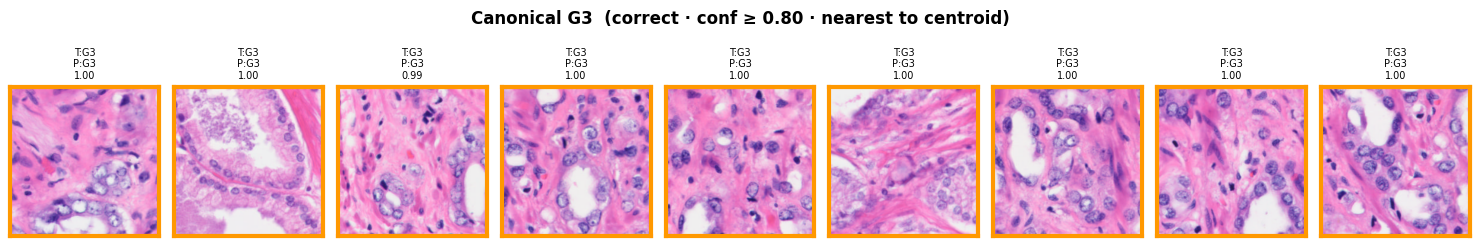

Canonical G4: 366 candidates


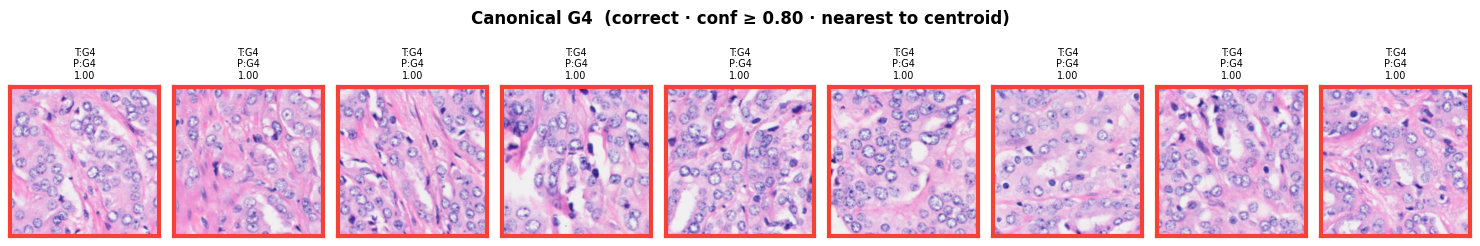

Canonical G5: 433 candidates


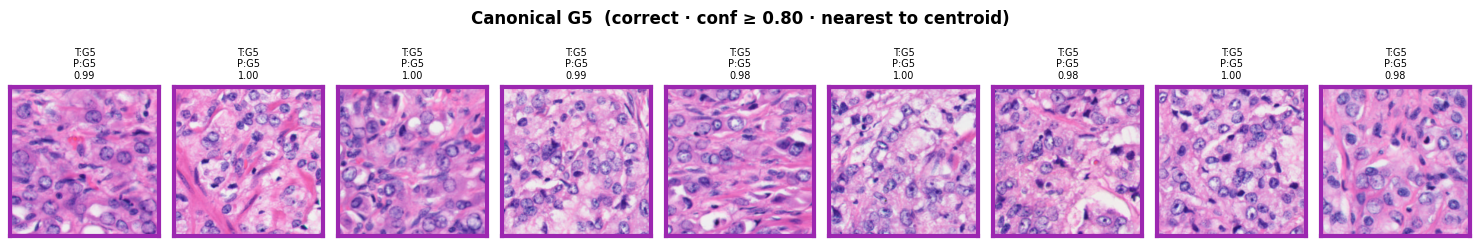

Ambiguous G3–G4 : 21 candidates


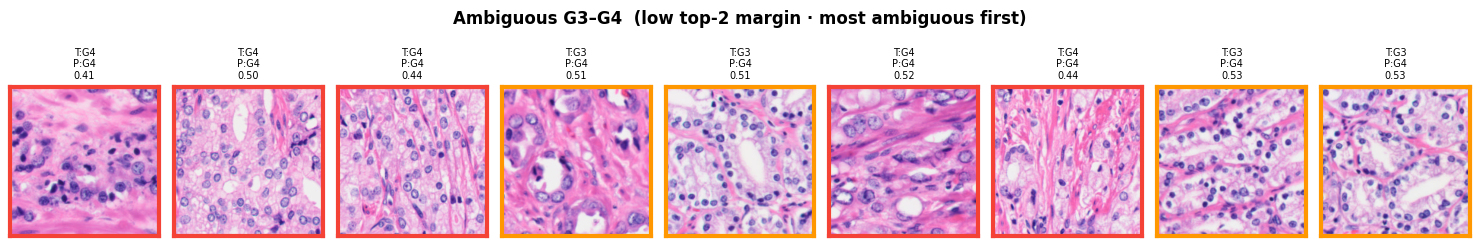

Ambiguous G4–G5 : 36 candidates


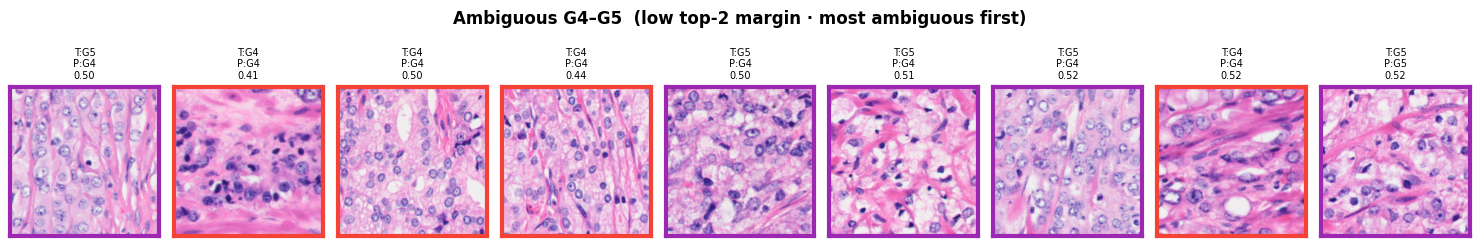

In [18]:
fig_dir = os.path.join(CONFIG['output_dir'], 'figures')

# ── Canonical prototypes ───────────────────────────────────────────────────────
for grade in ['G3', 'G4', 'G5']:
    mask = (
        (emb_df['true_label_name'] == grade) &
        (emb_df['pred_label_name'] == grade) &
        (emb_df['confidence'] >= 0.80)
    ).values
    print(f'Canonical {grade}: {mask.sum()} candidates')
    show_patch_panel(
        emb_df, emb_matrix, mask,
        title  = f'Canonical {grade}  (correct · conf ≥ 0.80 · nearest to centroid)',
        n      = 9,
        save_path = os.path.join(fig_dir, f'prototypes_canonical_{grade}.png'),
    )

# ── Ambiguous G3–G4 ───────────────────────────────────────────────────────────
mask_g34 = (
    emb_df['true_label_name'].isin(['G3', 'G4']) &
    emb_df['pred_label_name'].isin(['G3', 'G4']) &
    (emb_df['low_margin'] == 1)
).values
print(f'Ambiguous G3–G4 : {mask_g34.sum()} candidates')
show_patch_panel(
    emb_df, emb_matrix, mask_g34,
    title     = 'Ambiguous G3–G4  (low top-2 margin · most ambiguous first)',
    n         = 9,
    sort_key  = 'top2_margin',
    ascending = True,
    save_path = os.path.join(fig_dir, 'prototypes_ambiguous_G3G4.png'),
)

# ── Ambiguous G4–G5 ───────────────────────────────────────────────────────────
mask_g45 = (
    emb_df['true_label_name'].isin(['G4', 'G5']) &
    emb_df['pred_label_name'].isin(['G4', 'G5']) &
    (emb_df['low_margin'] == 1)
).values
print(f'Ambiguous G4–G5 : {mask_g45.sum()} candidates')
show_patch_panel(
    emb_df, emb_matrix, mask_g45,
    title     = 'Ambiguous G4–G5  (low top-2 margin · most ambiguous first)',
    n         = 9,
    sort_key  = 'top2_margin',
    ascending = True,
    save_path = os.path.join(fig_dir, 'prototypes_ambiguous_G4G5.png'),
)

## 7 · Quantification

Pairwise centroid distances, within-class compactness, progression score distributions,
and uncertainty vs progression score for the learned manifold.

**NTU G3 note:** If NTU G3 shows anomalously low classification accuracy or an outlier
progression score distribution, check label encoding before interpreting as a visual
difference. A 0-indexed vs 1-indexed label mismatch between cohorts would produce
systematic failure on that class independent of morphology.

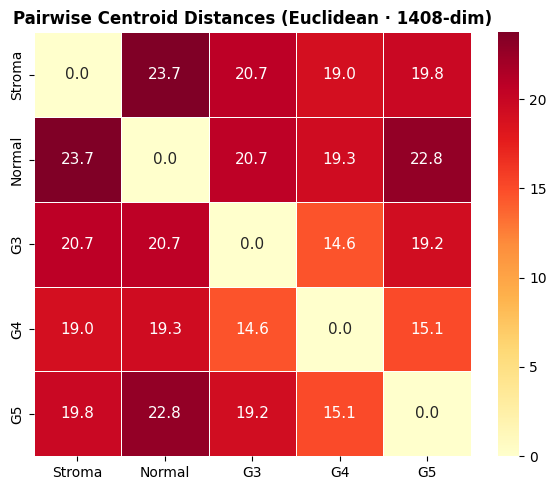


Within-class compactness (mean ± std Euclidean dist to own centroid):
  Stroma  : 15.78 ± 5.07
  Normal  : 18.42 ± 5.93
  G3      : 19.13 ± 5.43
  G4      : 18.65 ± 4.47
  G5      : 15.31 ± 4.76


In [19]:
fig_dir    = os.path.join(CONFIG['output_dir'], 'figures')
report_dir = os.path.join(CONFIG['output_dir'], 'reports')

# ── 1. Pairwise centroid distance heatmap ─────────────────────────────────────
centroid_mat  = np.vstack([class_centroids[c] for c in CLASS_NAMES])
pairwise_dist = pairwise_distances(centroid_mat, metric='euclidean')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    pairwise_dist,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, annot_kws={'size': 11},
)
ax.set_title('Pairwise Centroid Distances (Euclidean · 1408-dim)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'centroid_distance_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Within-class compactness ───────────────────────────────────────────────
print('\nWithin-class compactness (mean ± std Euclidean dist to own centroid):')
compactness = {}
for c in CLASS_NAMES:
    mask = emb_df['true_label_name'] == c
    vecs = emb_matrix[mask.values]
    d    = np.linalg.norm(vecs - class_centroids[c], axis=1)
    compactness[c] = (d.mean(), d.std())
    print(f'  {c:8s}: {d.mean():.2f} ± {d.std():.2f}')

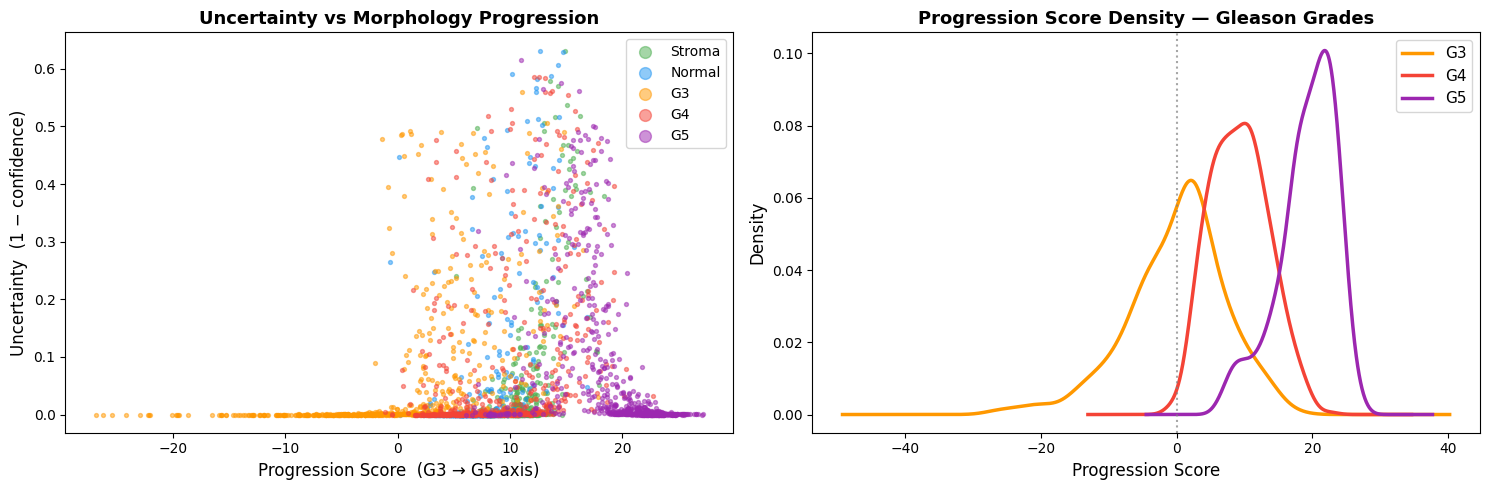

Saved → outputs/phase2/figures/uncertainty_vs_progression.png


In [20]:
emb_df['uncertainty'] = 1.0 - emb_df['confidence']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: uncertainty vs progression by class ─────────────────────────────────
ax = axes[0]
for c in CLASS_NAMES:
    m = emb_df['true_label_name'] == c
    ax.scatter(
        emb_df.loc[m, 'progression_score'],
        emb_df.loc[m, 'uncertainty'],
        c=CLASS_COLORS[c], label=c, s=8, alpha=0.5,
    )
ax.set_xlabel('Progression Score  (G3 → G5 axis)', fontsize=12)
ax.set_ylabel('Uncertainty  (1 − confidence)', fontsize=12)
ax.set_title('Uncertainty vs Morphology Progression', fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=10, framealpha=0.8)

# ── Right: progression score density per Gleason grade ───────────────────────
ax = axes[1]
for grade in ['G3', 'G4', 'G5']:
    vals = emb_df.loc[emb_df['true_label_name'] == grade, 'progression_score']
    vals.plot.kde(ax=ax, color=CLASS_COLORS[grade], linewidth=2.5, label=grade)
ax.set_xlabel('Progression Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Progression Score Density — Gleason Grades', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axvline(0, color='gray', linestyle=':', alpha=0.7)

plt.tight_layout()
fig_path = os.path.join(fig_dir, 'uncertainty_vs_progression.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

In [21]:
# ── G4 overlap: fraction of G4 patches closer to G3 or G5 centroid ────────────
g4_mask    = emb_df['true_label_name'] == 'G4'
g4_embs    = emb_matrix[g4_mask.values]
g4_dists   = pairwise_distances(g4_embs, np.vstack([class_centroids['G3'],
                                                      class_centroids['G4'],
                                                      class_centroids['G5']]),
                                  metric='euclidean')
# columns: [dist_G3, dist_G4, dist_G5]
nearest = np.argmin(g4_dists, axis=1)
n_g4 = g4_mask.sum()

print('G4 patch assignment by nearest centroid (G3/G4/G5 only):')
for i, label in enumerate(['G3', 'G4', 'G5']):
    cnt  = (nearest == i).sum()
    print(f'  Nearest to {label}: {cnt:4d} / {n_g4}  ({100*cnt/n_g4:.1f}%)')

print()
print('Interpretation:')
print('  If a substantial fraction of G4 patches are nearer to G3 or G5 centroids,')
print('  G4 occupies a diffuse transition region — not a compact isolated cluster.')

G4 patch assignment by nearest centroid (G3/G4/G5 only):
  Nearest to G3:   12 / 600  (2.0%)
  Nearest to G4:  524 / 600  (87.3%)
  Nearest to G5:   64 / 600  (10.7%)

Interpretation:
  If a substantial fraction of G4 patches are nearer to G3 or G5 centroids,
  G4 occupies a diffuse transition region — not a compact isolated cluster.


## 8 · Save Outputs

Persist all Phase II artefacts: combined embeddings CSV + NPY, progression/transition
CSV, and the text report to `outputs/phase2/`.

In [ ]:
emb_dir    = os.path.join(CONFIG['output_dir'], 'embeddings')
report_dir = os.path.join(CONFIG['output_dir'], 'reports')

# ── Save combined embeddings ──────────────────────────────────────────────────
emb_df.to_csv(os.path.join(emb_dir, 'embeddings_combined.csv'), index=False)
np.save(os.path.join(emb_dir, 'embeddings_combined.npy'), emb_matrix)

# ── Progression + transition ──────────────────────────────────────────────────
score_cols = [
    'path', 'source', 'true_label_name', 'pred_label_name',
    'confidence', 'correct', 'top2_margin', 'progression_score',
    'low_margin', 'near_boundary', 'transition', 'uncertainty',
]
emb_df[score_cols].to_csv(
    os.path.join(report_dir, 'progression_transition.csv'), index=False
)

# ── Text report ───────────────────────────────────────────────────────────────
lines = [
    'Phase II Report — Latent Space Analysis',
    '=' * 52,
    f'Total patches : {len(emb_df)}',
    '',
    'Per-source accuracy and Macro F1:',
]
for src_label in emb_df['source'].unique():
    sub = emb_df[emb_df['source'] == src_label]
    acc = sub['correct'].mean() * 100
    mf1 = f1_score(sub['true_label'], sub['pred_label'], average='macro') * 100
    lines.append(f'  {src_label:8s}: acc={acc:.2f}%  macro-F1={mf1:.2f}%')

lines += [
    '',
    'Transition patches (low_margin OR near_boundary):',
    f'  Total        : {emb_df["transition"].sum()} ({100*emb_df["transition"].mean():.1f}%)',
    f'  low_margin   : {emb_df["low_margin"].sum()}',
    f'  near_boundary: {emb_df["near_boundary"].sum()}',
    '',
    'Progression score (mean +/- std):',
]
for c in CLASS_NAMES:
    v = emb_df.loc[emb_df['true_label_name'] == c, 'progression_score']
    lines.append(f'  {c:8s}: {v.mean():+.3f} +/- {v.std():.3f}')

lines += ['', 'Note: progression axis is defined by G3 and G5 test-set centroids.',
          'G3/G5 ordering near axis endpoints is by construction.',
          'The meaningful finding is G4 width and its intermediate position.',
          '',
          'Within-class compactness (mean +/- std dist to centroid):']
for c, (m, s) in compactness.items():
    lines.append(f'  {c:8s}: {m:.2f} +/- {s:.2f}')

report_txt = '\n'.join(lines)
report_path = os.path.join(report_dir, 'phase2_report.txt')
with open(report_path, 'w') as f:
    f.write(report_txt)

print(report_txt)
print()
print('Phase II complete. Outputs:', CONFIG['output_dir'])